In [13]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,f1_score,recall_score

In [ ]:
classes = { "NORMAL" : 0 ,  "PNEUMONIA" : 1 }

# loads and preprocesses the data

X = []
Y = []

base_path = r"C:\Users\Tanishk\Desktop\Medical-Image-Classification\data\chest_xray"

for split in ['train', 'test', 'val']:
    split_path = os.path.join(base_path, split)
    for cls, label in classes.items():
        pth = os.path.join(split_path, cls)
        for filename in os.listdir(pth):
            img = cv2.imread(os.path.join(pth, filename), 0)
            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)
            Y.append(label)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(5856, 40000)
(5856,)


In [58]:
# splitting the data into training and testing sets

xtrain, xtest, ytrain, ytest = train_test_split( X,Y,
    random_state=10,   # produces the same random split every time
    test_size=0.8      # 80% data is used for testing
)

# reduces dimensionality
pca = PCA(n_components=0.98)  # keeps 98% of data variance
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

sv= SVC(kernel="rbf")
sv.fit(pca_train, ytrain)
train_score=sv.score(pca_train, ytrain)
test_score=sv.score(pca_test, ytest)

print("training accuracy:",train_score)
print("testing accuracy:",test_score)


training accuracy: 0.9837745516652434
testing accuracy: 0.9466382070437567


In [59]:
# Make predictions on test data
y_pred = sv.predict(pca_test)

# Generate confusion matrix
cm = confusion_matrix(ytest, y_pred) #rows represent actual classes and columns represent predicted classes
print("Confusion Matrix:")
print(cm)

#calculating recall
sensitivity = recall_score(ytest, y_pred, average='weighted')
print("\nsensitivity:",sensitivity) #true poitive rate , recall = TP / (TP + FN)

#calculating specificity
specificities = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)
    specificities.append(specificity)

specificity = np.mean(specificities)
print("specificity:",specificity) #true negative rate, specificity = TN / (TN + FP)

#f1 score
f1 = f1_score(ytest, y_pred, average='weighted') #f1 score = 2 * ((precision * recall)/(precision + recall))
print("F1 Score:", f1)


#classification report
report = classification_report(ytest, y_pred)
print("\nClassification Report:\n", report)

Confusion Matrix:
[[1112  164]
 [  86 3323]]

sensitivity: 0.9466382070437567
specificity: 0.9231230074181289
F1 Score: 0.9460987997549574

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90      1276
           1       0.95      0.97      0.96      3409

    accuracy                           0.95      4685
   macro avg       0.94      0.92      0.93      4685
weighted avg       0.95      0.95      0.95      4685



In [28]:
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200))
        img_flat = img.flatten() / 255.0
        prediction = sv.predict(
            pca.transform([img_flat])
        )
        dec = {
            0: 'Normal',
            1: 'Pneumonia'
        }
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

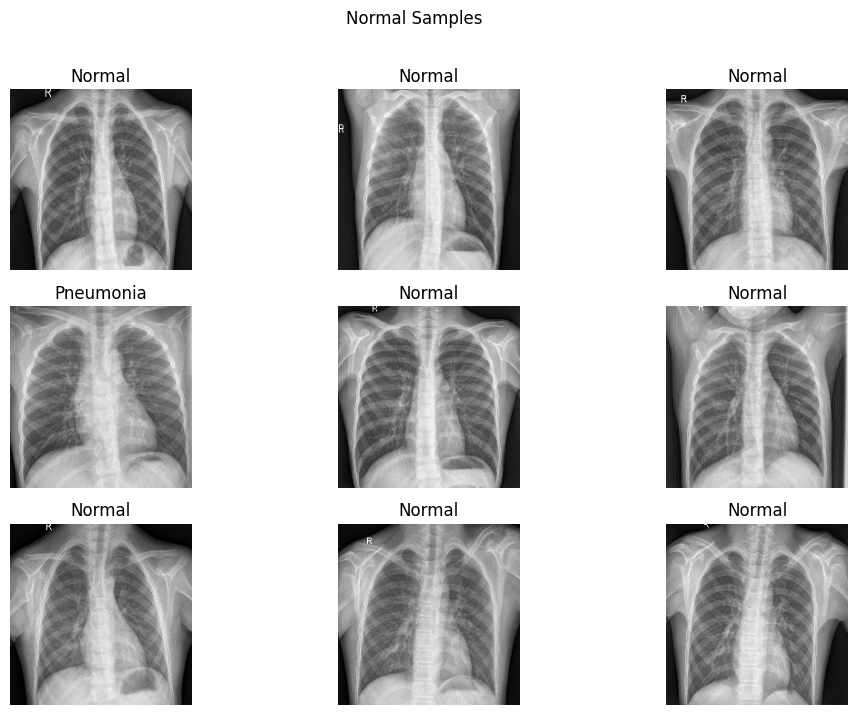

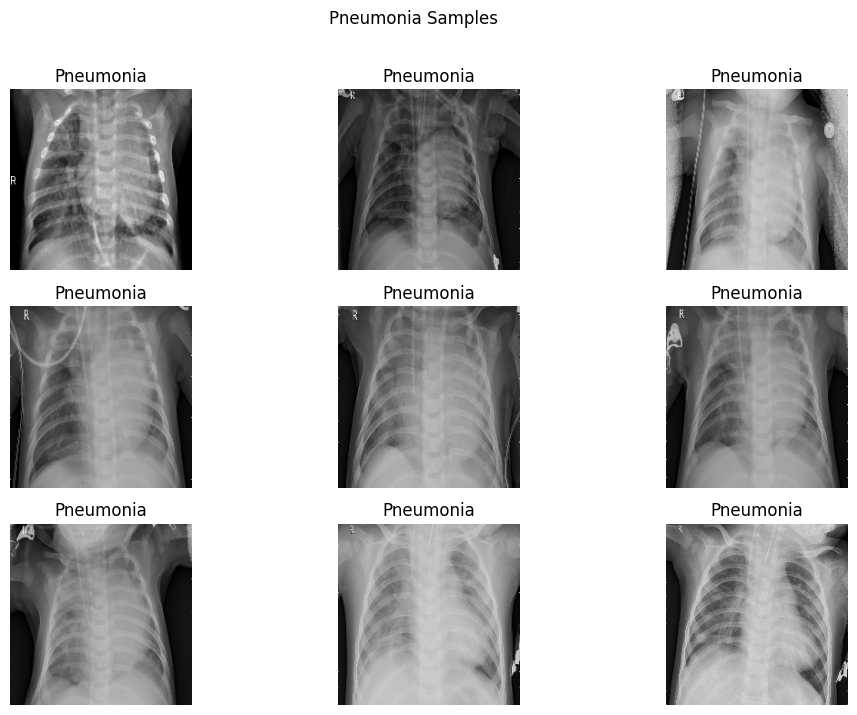

In [29]:
# Define class labels
dec = {0: 'Normal',1: 'Pneumonia'}
# Display sample images and predictions
xray_folders = ['NORMAL', 'PNEUMONIA']
for xray_folder in xray_folders:
    folder_path = rf"C:\Users\Tanishk\Desktop\Medical-Image-Classification\data\chest_xray\test\{xray_folder}"
    title = f'{xray_folder.title()} Samples'
    display_samples(folder_path, title)

In [41]:
# Define class labels

dec = {0: 'Normal',1: 'Pneumonia'}

# Count the occurrences of each class
xray_counts = {
    dec[label]: np.sum(Y == label)
    for label in classes.values()
}
# Create a table
table_data = {'Index': range(1, len(classes) + 1),'Class': list(xray_counts.keys()),'Count': list(xray_counts.values())}
xray_table = pd.DataFrame(table_data)

# Apply styling
styled_table = xray_table.style.set_properties(
    **{'border': '3px solid black','text-align': 'center'}
)

print("\033[1mChest X-ray Class Counts:\033[0m")
display(styled_table)

Chest X-ray Class Counts:


,Index,Class,Count
0,1,Normal,1583
1,2,Pneumonia,4273


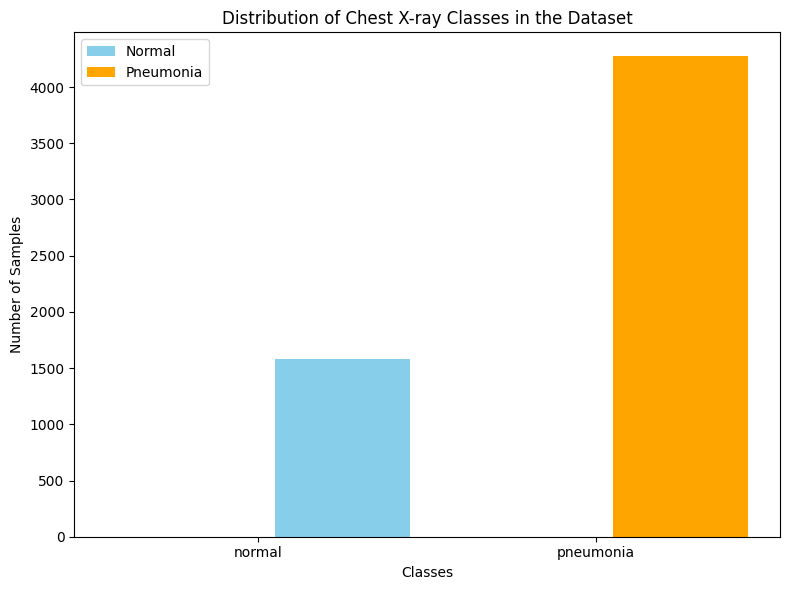

In [16]:
# Create histogram of Chest X-ray classes

xray_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange']
plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):

    plt.hist(
        np.array(xray_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])

plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('Distribution of Chest X-ray Classes in the Dataset')

plt.xticks(
    range(len(classes)),
    list(classes.keys())
)
plt.legend()
plt.tight_layout()
plt.show()